In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content
!mkdir -p /content/workspace

# Use the real Drive path you showed: space_station_hackathon
!DRIVE_ROOT="/content/drive/MyDrive/space_station_hackathon"

# create or refresh the symlink
!ln -sfn "$DRIVE_ROOT" /content/workspace/data_root

# list the linked folder to confirm
!ls -la /content/workspace
!ls -la /content/workspace/data_root


/content
ln: failed to create symbolic link '/content/workspace/data_root' -> '': No such file or directory
total 8
drwxr-xr-x 2 root root 4096 Nov 26 07:29 .
drwxr-xr-x 1 root root 4096 Nov 26 07:29 ..
ls: cannot access '/content/workspace/data_root': No such file or directory


In [ ]:
!echo "Hackathon2_scripts contents:"
!ls -la /content/workspace/data_root/Hackathon2_scripts
!echo "classes.txt preview:"
!sed -n '1,200p' /content/workspace/data_root/Hackathon2_scripts/classes.txt || true


Hackathon2_scripts contents:
ls: cannot access '/content/workspace/data_root/Hackathon2_scripts': No such file or directory
classes.txt preview:
sed: can't read /content/workspace/data_root/Hackathon2_scripts/classes.txt: No such file or directory


In [ ]:
import os, yaml

drive_root = '/content/workspace/data_root'
classes_txt = os.path.join(drive_root, 'Hackathon2_scripts', 'classes.txt')

if not os.path.exists(classes_txt):
    raise FileNotFoundError(f"classes.txt not found at {classes_txt}")

with open(classes_txt,'r') as f:
    names = [line.strip() for line in f if line.strip()]
print('Detected classes ({}):'.format(len(names)), names)

data = {
    'train': os.path.join(drive_root, 'train_2', 'train2', 'images'),
    'val':   os.path.join(drive_root, 'train_2', 'val2', 'images'),
    'test':  os.path.join(drive_root, 'test1', 'images'),
    'nc': len(names),
    'names': names
}

out_path = '/content/workspace/yolo_data.yaml'
os.makedirs('/content/workspace', exist_ok=True)
with open(out_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
print('Wrote', out_path)
print(open(out_path).read())


FileNotFoundError: classes.txt not found at /content/workspace/data_root/Hackathon2_scripts/classes.txt

In [ ]:
!echo "Train images (sample):"
!ls -la /content/workspace/data_root/train_2/train2/images | head -n 20

!echo "Train labels (sample):"
!ls -la /content/workspace/data_root/train_2/train2/labels | head -n 20

!echo "Val images (sample):"
!ls -la /content/workspace/data_root/train_2/val2/images | head -n 20

!echo "Test images (sample):"
!ls -la /content/workspace/data_root/test1/images | head -n 20


In [ ]:
!yolo detect train \
    data=/content/workspace/yolo_data.yaml \
    model=yolov8s.pt \
    imgsz=640 \
    batch=4 \
    epochs=1 \
    project=/content/drive/MyDrive/space_station_hackathon/runs \
    name=debug_v8


In [ ]:
!yolo detect train \
  data=/content/workspace/yolo_data.yaml \
  model=yolov8s.pt \
  imgsz=640 \
  batch=4 \
  epochs=50 \
  project=/content/drive/MyDrive/space_station_hackathon/runs \
  name=yolov8_final \
  augment=True \
  patience=30 \
  save_period=1


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# show shared drives and target folder
!ls -la "/content/drive/Shared drives" || true
!ls -la "/content/drive/Shared drives/Hackathon Drive/space_station_hackathon" || true

# check weights exist
!ls -la "/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights" || true


Mounted at /content/drive
total 4
drwx------ 1 root root 4096 Nov 26 05:58 'Hackathon Drive'
total 1643194
drwx------ 2 root root       4096 Nov 24 22:40 Hackathon2_scripts
drwx------ 2 root root       4096 Nov 25 20:04 runs
drwx------ 2 root root       4096 Nov 26 16:51 submission_package
-rw------- 1 root root 1682609820 Nov 26 17:00 submission_package.zip
drwx------ 2 root root       4096 Nov 24 22:40 test1
drwx------ 2 root root       4096 Nov 24 22:40 train_2
total 3457950
-rw------- 1 root root 44742711 Nov 26 17:13 best.onnx
-rw------- 1 root root 44763962 Nov 26 17:13 best.pb
-rw------- 1 root root 22498858 Nov 25 22:52 best.pt
drwx------ 2 root root     4096 Nov 26 17:12 best_saved_model
-rw------- 1 root root 44914654 Nov 26 16:01 best.torchscript
drwx------ 2 root root     4096 Nov 26 17:13 best_web_model
-rw------- 1 root root 67227107 Nov 25 20:37 epoch0.pt
-rw------- 1 root root 67228131 Nov 25 21:05 epoch10.pt
-rw------- 1 root root 67228259 Nov 25 21:08 epoch11.pt
-rw--

In [ ]:
# search for the folder within the mounted drive (may take a few seconds)
%%shell
echo "Searching for 'space_station_hackathon' under /content/drive (this may take 5-10s)..."
find /content/drive -maxdepth 5 -type d -iname "space_station_hackathon" -print || true

# Also look for any directory named 'Hackathon Drive' (in case the parent is named differently)
echo "Searching for 'Hackathon Drive' (shared drive) paths..."
find /content/drive -maxdepth 5 -type d -iname "Hackathon Drive" -print || true
# This will take the first match from find and use it as SHARED_ROOT.
FOUND=$(find /content/drive -maxdepth 5 -type d -iname "space_station_hackathon" -print | head -n 1)
echo "Found: '$FOUND'"

if [ -z "$FOUND" ]; then
  echo "No space_station_hackathon folder found. Please check shared drive membership or run the 'find' cell above and paste the path here."
else
  # make workspace and symlink
  mkdir -p /content/workspace
  ln -sfn "$FOUND" /content/workspace/data_root
  echo "Created symlink:"
  ls -la /content/workspace || true
  echo ""
  echo "Verify linked folder contents:"
  ls -la /content/workspace/data_root || true
fi


Searching for 'space_station_hackathon' under /content/drive (this may take 5-10s)...
/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon
Searching for 'Hackathon Drive' (shared drive) paths...
/content/drive/Shareddrives/Hackathon Drive
Found: '/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon'
Created symlink:
total 12
drwxr-xr-x 2 root root 4096 Nov 26 17:26 .
drwxr-xr-x 1 root root 4096 Nov 26 17:26 ..
lrwxrwxrwx 1 root root   67 Nov 26 17:26 data_root -> '/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon'

Verify linked folder contents:
lrwxrwxrwx 1 root root 67 Nov 26 17:26 /content/workspace/data_root -> '/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon'


In [ ]:
# Install/upgrade
!pip install -q -U pip
!pip install -q -U ultralytics

# quick check
import ultralytics, torch; print('ultralytics', ultralytics.__version__, 'torch', torch.__version__)
!nvidia-smi || true


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.3.232 torch 2.9.0+cu126
/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# list run folder and weights
!ls -la "/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs" || true
!ls -la "/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights" || true


total 24
drwx------ 2 root root 4096 Nov 25 20:04 debug_v8
drwx------ 2 root root 4096 Nov 26 08:01 inference_final
drwx------ 2 root root 4096 Nov 26 15:33 inference_submission
drwx------ 2 root root 4096 Nov 26 16:04 inference_submission2
drwx------ 3 root root 4096 Nov 25 20:34 yolov8_final
drwx------ 2 root root 4096 Nov 26 08:49 yolov8m_finetune
total 3457950
-rw------- 1 root root 44742711 Nov 26 17:13 best.onnx
-rw------- 1 root root 44763962 Nov 26 17:13 best.pb
-rw------- 1 root root 22498858 Nov 25 22:52 best.pt
drwx------ 2 root root     4096 Nov 26 17:12 best_saved_model
-rw------- 1 root root 44914654 Nov 26 16:01 best.torchscript
drwx------ 2 root root     4096 Nov 26 17:13 best_web_model
-rw------- 1 root root 67227107 Nov 25 20:37 epoch0.pt
-rw------- 1 root root 67228131 Nov 25 21:05 epoch10.pt
-rw------- 1 root root 67228259 Nov 25 21:08 epoch11.pt
-rw------- 1 root root 67228387 Nov 25 21:11 epoch12.pt
-rw------- 1 root root 67228515 Nov 25 21:13 epoch13.pt
-rw------

In [ ]:
# create yolo_data.yaml pointing to the symlinked shared drive
import os, yaml

DRIVE_ROOT = '/content/workspace/data_root'
classes_txt = os.path.join(DRIVE_ROOT, 'Hackathon2_scripts', 'classes.txt')

if not os.path.exists(classes_txt):
    raise FileNotFoundError(f"classes.txt not found at {classes_txt}")

with open(classes_txt,'r') as f:
    names = [line.strip() for line in f if line.strip()]

data = {
    'train': os.path.join(DRIVE_ROOT, 'train_2', 'train2', 'images'),
    'val':   os.path.join(DRIVE_ROOT, 'train_2', 'val2', 'images'),
    'test':  os.path.join(DRIVE_ROOT, 'test1', 'images'),
    'nc': len(names),
    'names': names
}

out_path = '/content/workspace/yolo_data.yaml'
os.makedirs('/content/workspace', exist_ok=True)
with open(out_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print("Wrote", out_path)
print(open(out_path).read())


Wrote /content/workspace/yolo_data.yaml
train: /content/workspace/data_root/train_2/train2/images
val: /content/workspace/data_root/train_2/val2/images
test: /content/workspace/data_root/test1/images
nc: 7
names:
- OxygenTank
- NitrogenTank
- FirstAidBox
- FireAlarm
- SafetySwitchPanel
- EmergencyPhone
- FireExtinguisher



In [ ]:
# validate using best checkpoint (prints mAP and per-class mAP)
!yolo detect val data=/content/workspace/yolo_data.yaml model="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt"


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 81.9±176.9 MB/s, size: 3095.5 KB)
val: Scanning /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/train_2/val2/labels.cache... 336 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 336/336 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.1s/it 23.4s
                   all        336        957      0.927      0.753      0.829      0.701
            OxygenTank        135        237      0.947      0.823       0.88      0.805
          NitrogenTank        157        283      0.906      0.781      0.856       0.75
           FirstAidBox         97        119      0.896      0.801      0.864      0.772
             FireAlarm         55         57      0.937      0.779       0.87

In [ ]:
!yolo detect predict \
  model="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt" \
  source="/content/workspace/data_root/test1/images" \
  project="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs" \
  name="inference_final" \
  save=True


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

image 1/1408 /content/workspace/data_root/test1/images/000000001_light_unclutter.png: 384x640 1 NitrogenTank, 1 FirstAidBox, 46.9ms
image 2/1408 /content/workspace/data_root/test1/images/000000001_vdark_clutter.png: 384x640 1 OxygenTank, 2 NitrogenTanks, 2 FirstAidBoxs, 1 FireExtinguisher, 10.7ms
image 3/1408 /content/workspace/data_root/test1/images/000000002_dark_clutter.png: 384x640 1 OxygenTank, 11.5ms
image 4/1408 /content/workspace/data_root/test1/images/000000002_vlight_unclutter.png: 384x640 1 OxygenTank, 10.7ms
image 5/1408 /content/workspace/data_root/test1/images/000000003_vdark_unclutter.png: 384x640 1 OxygenTank, 2 SafetySwitchPanels, 10.7ms
image 6/1408 /content/workspace/data_root/test1/images/000000006_dark_unclutter.png: 384x640 (no detections), 12.0ms
image 7/1408 /content/workspace/data_root/test1/images

In [ ]:
%%shell
BASE="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon"
OUT="$BASE/submission_package"
mkdir -p "$OUT"

cp "$BASE/runs/yolov8_final/weights/best.pt" "$OUT/" || true
cp "$BASE/runs/yolov8_final/weights/last.pt" "$OUT/" || true
cp "$BASE/runs/yolov8_final/results.png" "$OUT/" || true
cp "$BASE/runs/yolov8_final/labels.jpg" "$OUT/" || true
cp "$BASE/runs/yolov8_final/confusion_matrix.png" "$OUT/" || true
cp /content/workspace/yolo_data.yaml "$OUT/" || true
cp "$BASE/Hackathon2_scripts/classes.txt" "$OUT/" || true

mkdir -p "$OUT/inference_examples"
cp -r "$BASE/runs/inference_final/images" "$OUT/inference_examples" || true

cd "$BASE"
zip -r submission_package.zip submission_package || true
ls -la submission_package*


cp: cannot stat '/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/inference_final/images': No such file or directory
  adding: submission_package/ (stored 0%)
  adding: submission_package/best.pt (deflated 8%)
  adding: submission_package/last.pt (deflated 8%)
  adding: submission_package/results.png (deflated 8%)
  adding: submission_package/labels.jpg (deflated 24%)
  adding: submission_package/confusion_matrix.png (deflated 19%)
  adding: submission_package/yolo_data.yaml (deflated 45%)
  adding: submission_package/classes.txt (deflated 16%)
  adding: submission_package/inference_examples/ (stored 0%)
-rw------- 1 root root 41975063 Nov 26 08:10 submission_package.zip

submission_package:
total 44647
-rw------- 1 root root 22498858 Nov 26 08:10 best.pt
-rw------- 1 root root      103 Nov 26 08:10 classes.txt
-rw------- 1 root root   237009 Nov 26 08:10 confusion_matrix.png
drwx------ 2 root root     4096 Nov 26 08:10 inference_examples
-rw------- 1 root root

In [ ]:
# update these if your paths differ
BASE = "/content/drive/Shared drives/Hackathon Drive/space_station_hackathon"
WORKSPACE = "/content/workspace"
DATA_YAML = f"{WORKSPACE}/yolo_data.yaml"
BEST_PT = f"{BASE}/runs/yolov8_final/weights/best.pt"
LAST_PT = f"{BASE}/runs/yolov8_final/weights/last.pt"
TRAIN_IMAGES = f"{WORKSPACE}/data_root/train_2/train2/images"
TRAIN_LABELS = f"{WORKSPACE}/data_root/train_2/train2/labels"
VAL_IMAGES = f"{WORKSPACE}/data_root/train_2/val2/images"
VAL_LABELS = f"{WORKSPACE}/data_root/train_2/val2/labels"
TEST_IMAGES = f"{WORKSPACE}/data_root/test1/images"
CLASSES_FILE = f"{WORKSPACE}/data_root/Hackathon2_scripts/classes.txt"

print("Paths set.\nBEST_PT:", BEST_PT)


Paths set.
BEST_PT: /content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt


In [ ]:
from collections import Counter
import glob, os
labels_dir = TRAIN_LABELS
files = glob.glob(os.path.join(labels_dir,"*.txt"))
counter = Counter()
for f in files:
    for line in open(f):
        cls = int(line.split()[0])
        counter[cls] += 1

names = [l.strip() for l in open(CLASSES_FILE)]
print("Class counts (train):")
for i,n in enumerate(names):
    print(f"{i:2d} {n:20s} {counter[i]:5d}")


Class counts (train):
 0 OxygenTank            1410
 1 NitrogenTank          1574
 2 FirstAidBox            709
 3 FireAlarm              300
 4 SafetySwitchPanel      380
 5 EmergencyPhone         393
 6 FireExtinguisher       705


In [ ]:
import os, glob, shutil, random, cv2
from pathlib import Path
import numpy as np

THRESH = 500   # threshold below which we will augment/duplicate
DUPS = 2       # how many augmented copies to create for each rare image
labels_dir = TRAIN_LABELS
imgs_dir = TRAIN_IMAGES
classes = [l.strip() for l in open(CLASSES_FILE)]

# count per class
from collections import defaultdict
class_files = defaultdict(list)
for lab in glob.glob(os.path.join(labels_dir,"*.txt")):
    with open(lab) as f:
        lines = [l.strip() for l in f if l.strip()]
    cls_ids = {int(l.split()[0]) for l in lines}
    for c in cls_ids:
        class_files[c].append(lab)

# decide rare classes
from collections import Counter
cnt = Counter()
for k,v in class_files.items():
    cnt[k] = len(v)
print("Counts:", dict(cnt))

rare = [c for c,n in cnt.items() if n < THRESH]
print("Rare classes (will augment):", rare)

def augment_image(img):
    # simple augmentations: flip, rotate small angle, brightness change
    h,w = img.shape[:2]
    choice = random.choice(['flip','rot','bright','none'])
    if choice=='flip':
        return cv2.flip(img, 1)
    elif choice=='rot':
        angle = random.uniform(-12,12)
        M = cv2.getRotationMatrix2D((w/2,h/2), angle, 1.0)
        return cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REPLICATE)
    elif choice=='bright':
        factor = random.uniform(0.7,1.3)
        img2 = (img.astype(float)*factor).clip(0,255).astype(np.uint8)
        return img2
    else:
        return img

created = 0
for cls in rare:
    files = class_files[cls]
    for lab in files:
        base = Path(lab).stem
        img_path = None
        for ext in ['.png','.jpg','.jpeg']:
            p = os.path.join(imgs_dir, base+ext)
            if os.path.exists(p):
                img_path = p; break
        if not img_path:
            continue
        img = cv2.imread(img_path)
        for i in range(DUPS):
            new_base = f"{base}_dup_c{cls}_{i}"
            new_img_path = os.path.join(imgs_dir, new_base + Path(img_path).suffix)
            new_lab_path = os.path.join(labels_dir, new_base + ".txt")
            aug = augment_image(img)
            cv2.imwrite(new_img_path, aug)
            shutil.copyfile(lab, new_lab_path)
            created += 1

print(f"Created {created} augmented duplicates for rare classes. Re-run training.")


Counts: {1: 853, 2: 520, 6: 514, 0: 823, 3: 269, 5: 315, 4: 331}
Rare classes (will augment): [3, 5, 4]
Created 1830 augmented duplicates for rare classes. Re-run training.


In [ ]:
# fine-tune yolov8m from your best small-model checkpoint
!yolo detect train \
  data=/content/workspace/yolo_data.yaml \
  model="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt" \
  imgsz=640 \
  batch=2 \
  epochs=80 \
  project="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs" \
  name="yolov8m_finetune" \
  augment=True \
  save_period=1 \
  patience=30 \
  optimizer=AdamW


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/workspace/yolo_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8m_finetune, nbs=64, nms=False, opset=

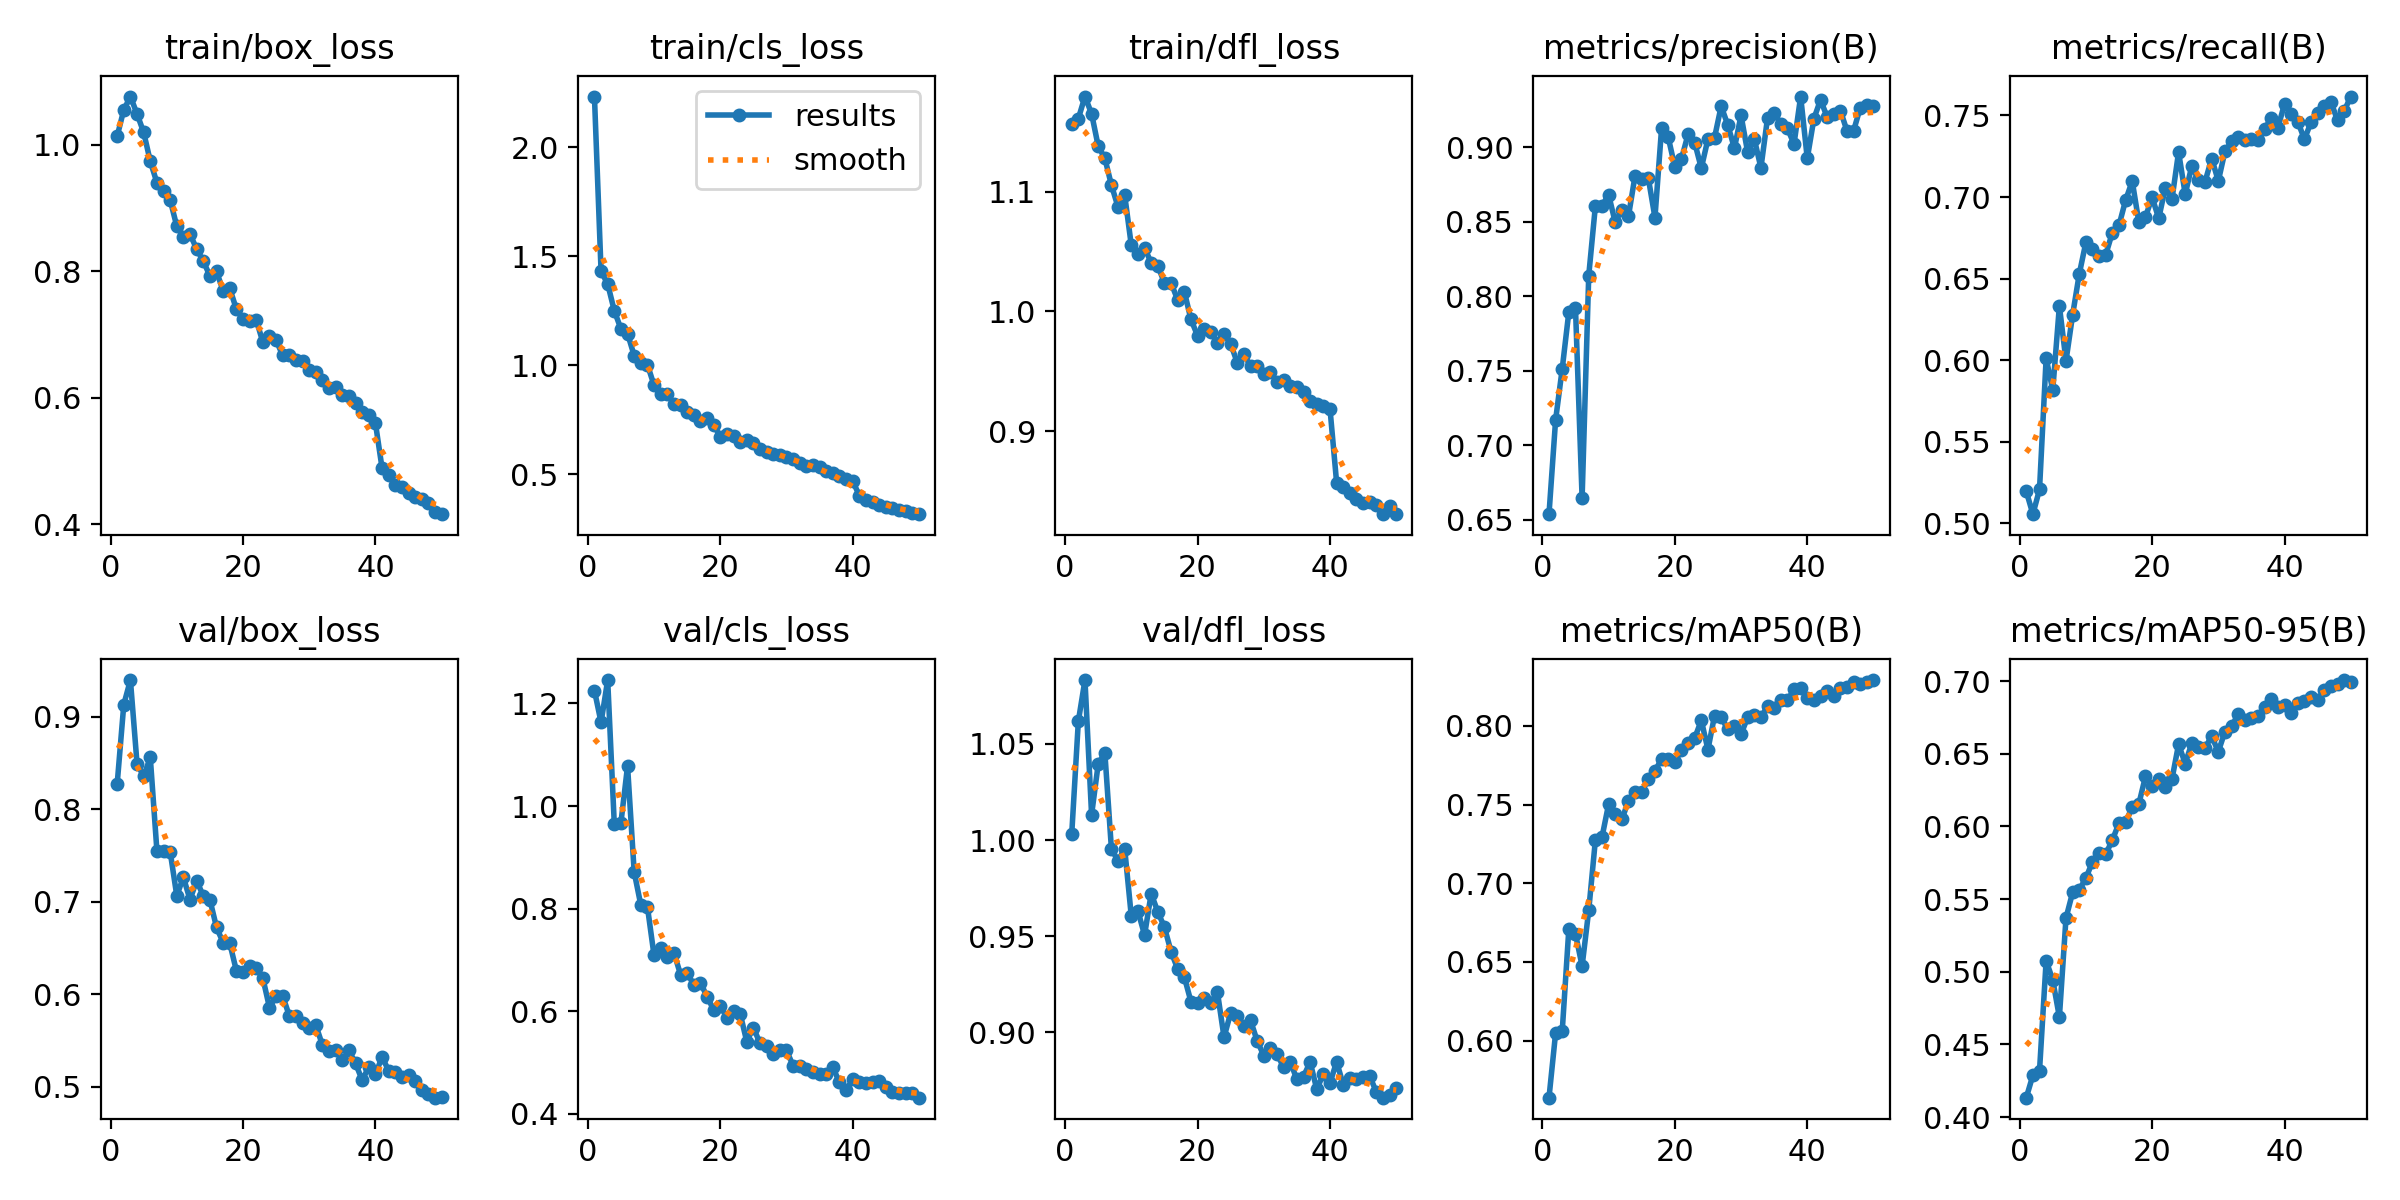

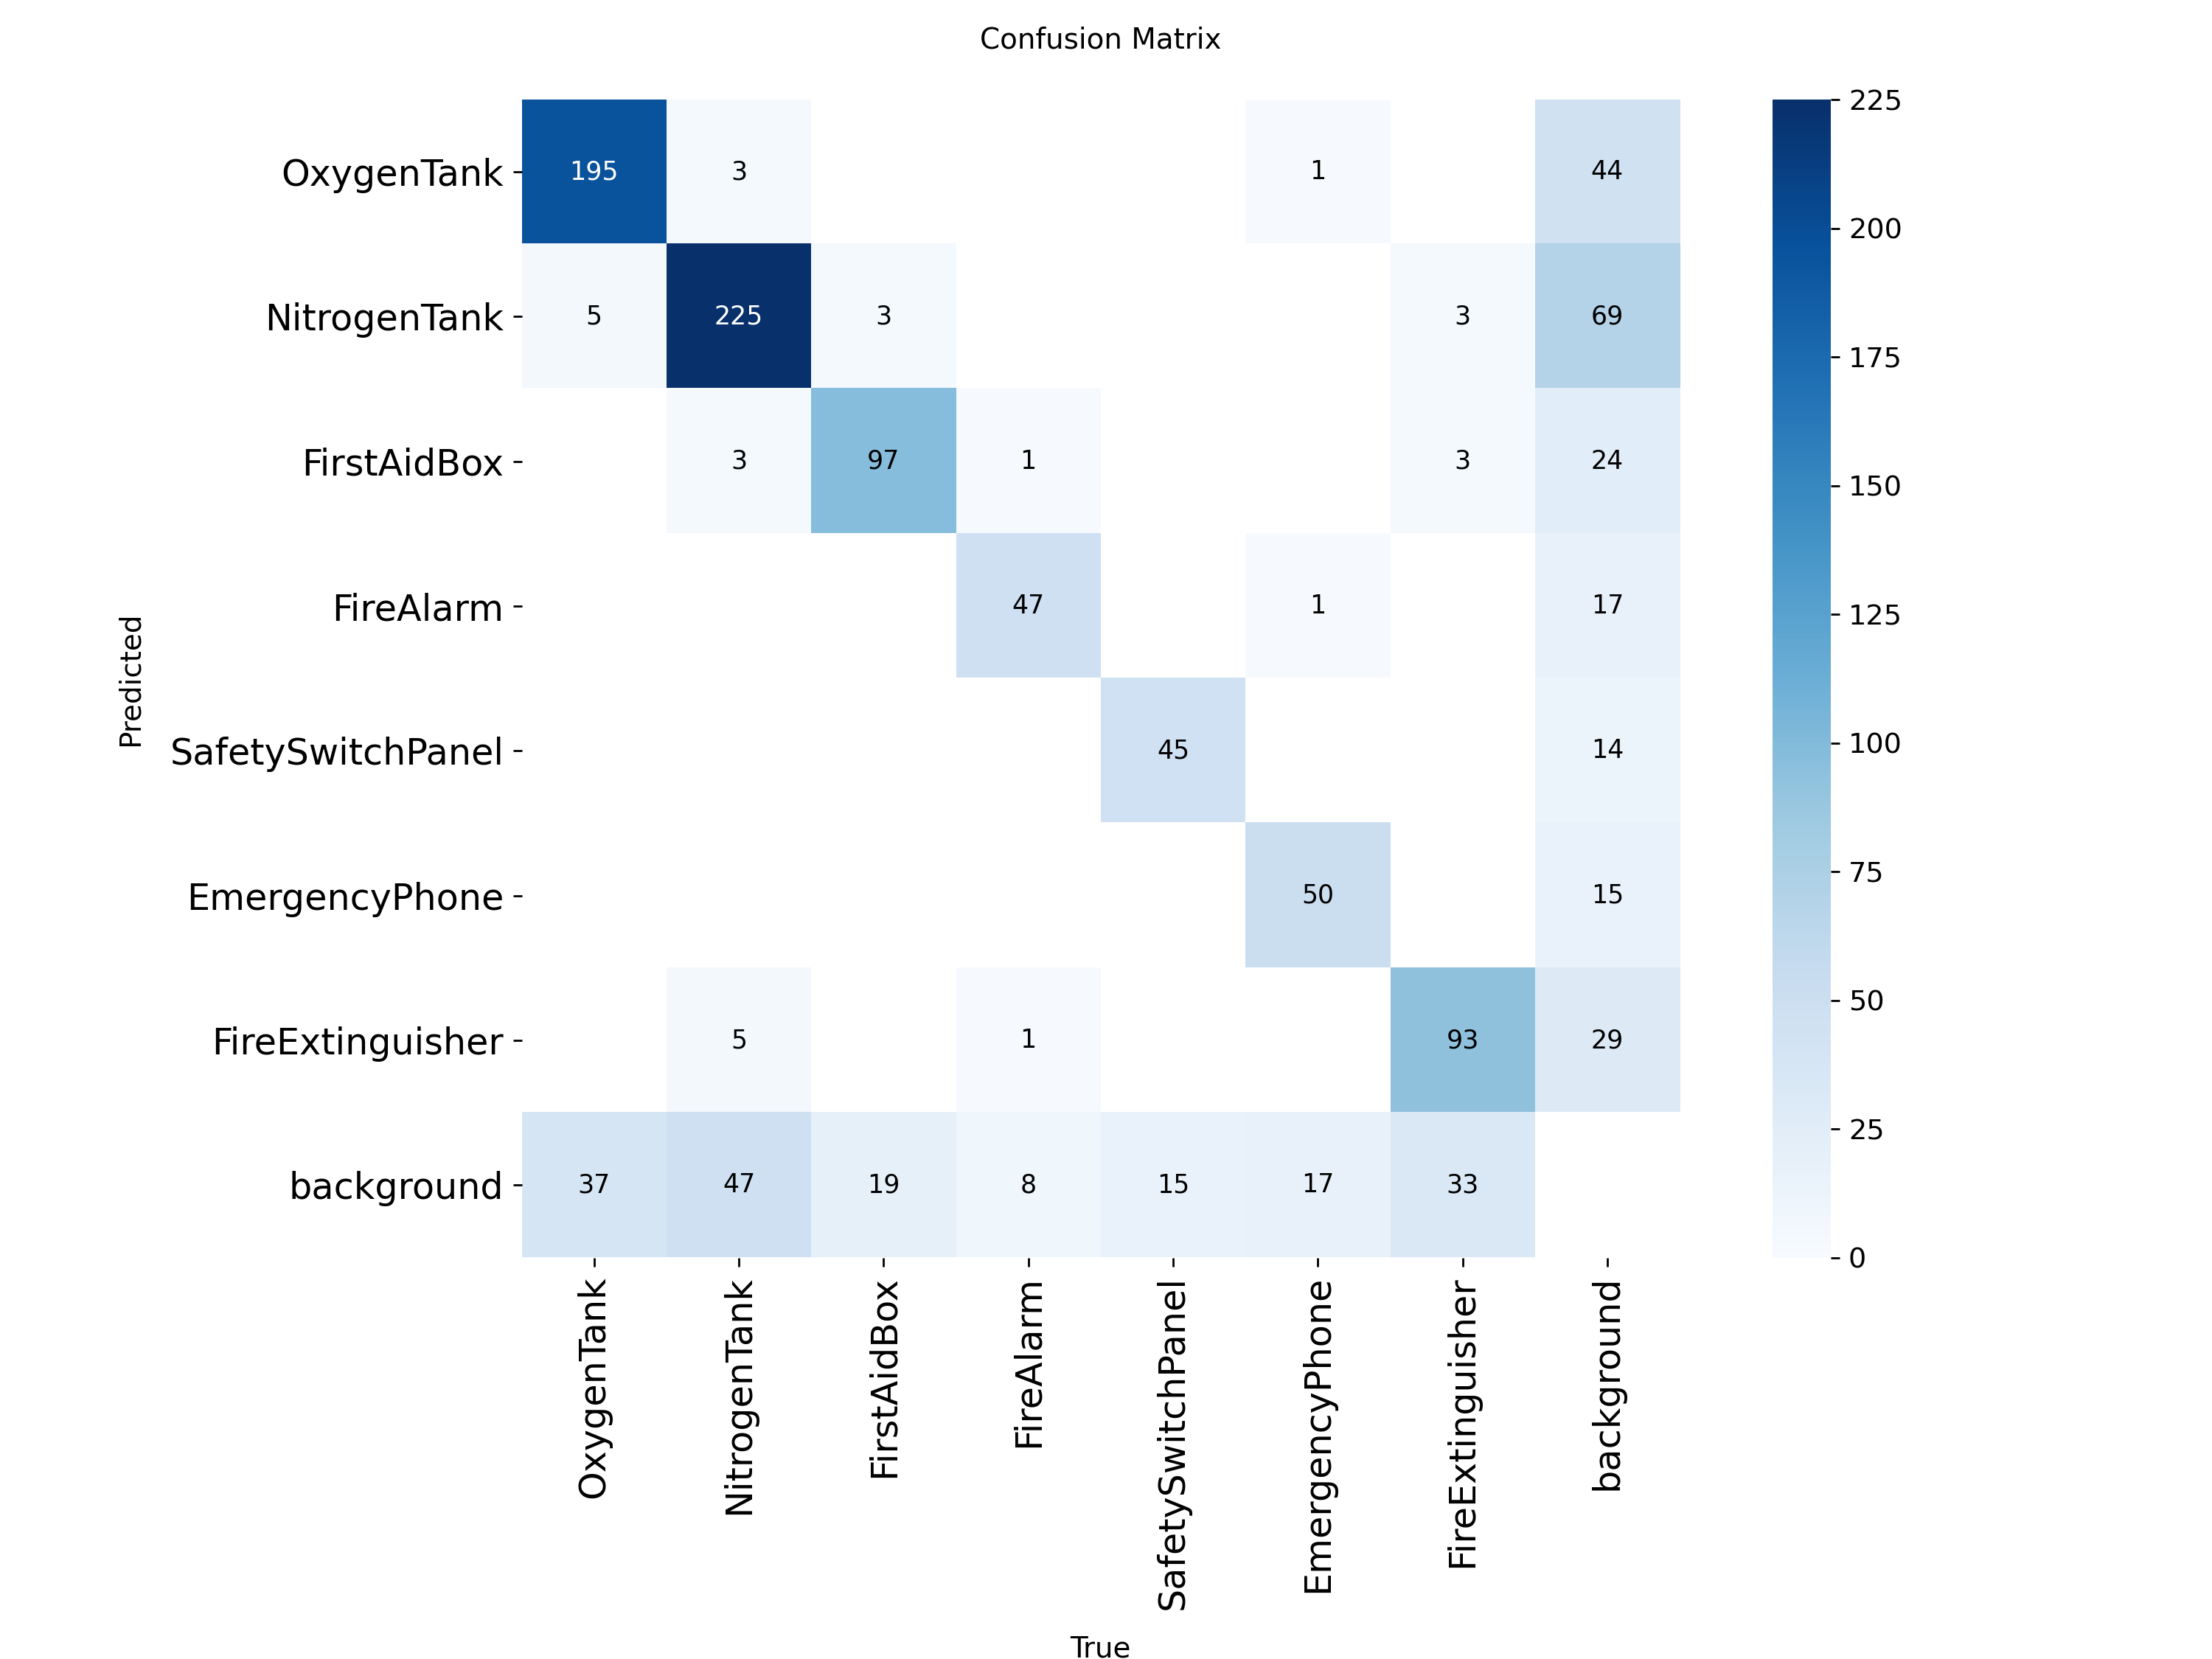

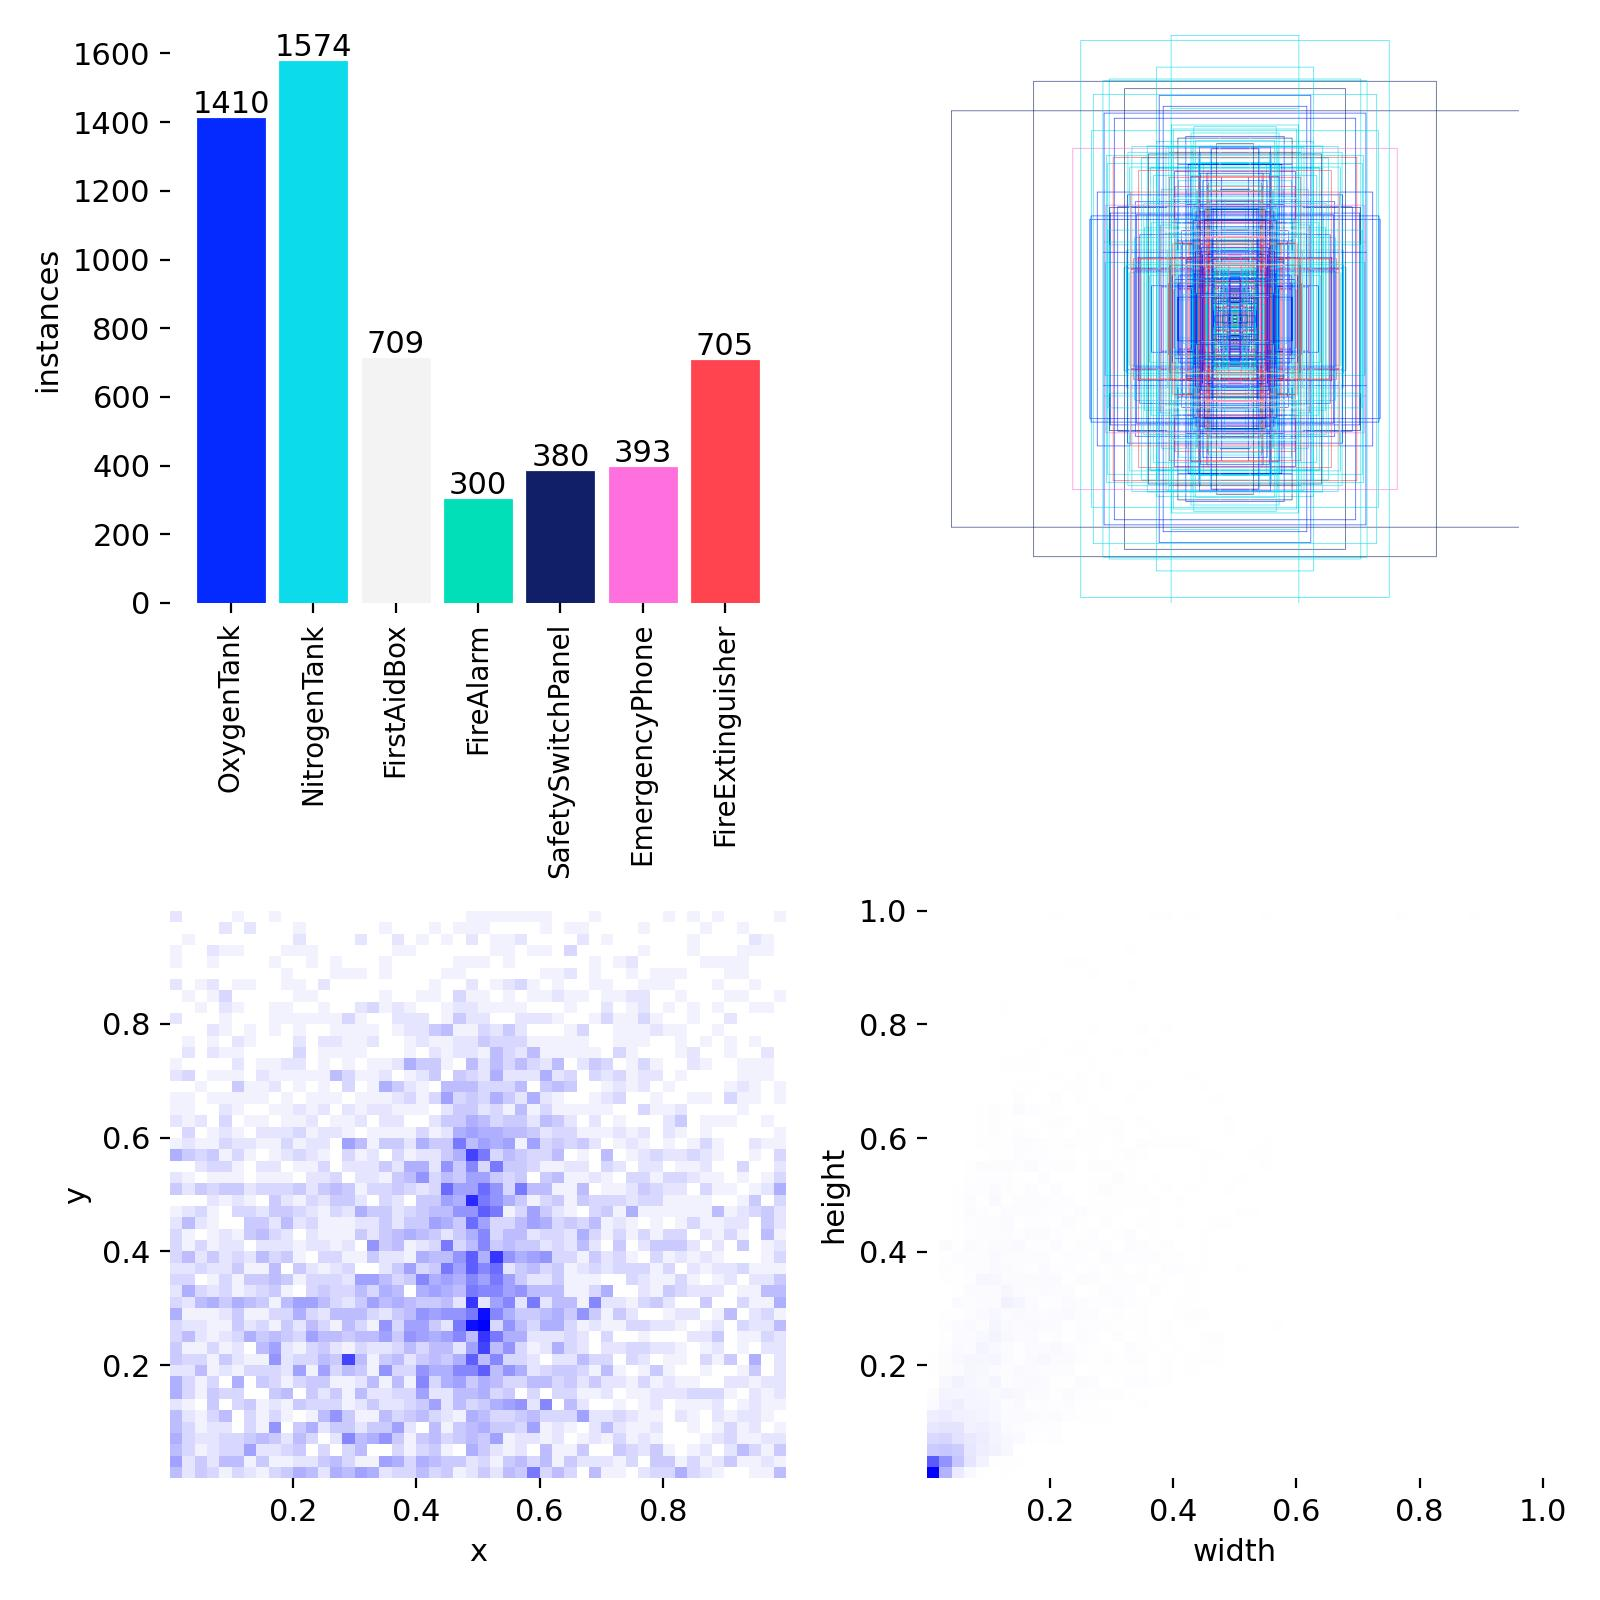

In [ ]:
from IPython.display import Image, display
display(Image("/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/results.png"))
display(Image("/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/confusion_matrix.png"))
display(Image("/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/labels.jpg"))


In [ ]:
!yolo detect predict \
  model="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt" \
  source="/content/workspace/data_root/test1/images" \
  project="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs" \
  name="inference_submission" \
  save=True \
  save_txt=True \
  conf=0.25 \
  iou=0.45


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

image 1/1408 /content/workspace/data_root/test1/images/000000001_light_unclutter.png: 384x640 1 NitrogenTank, 1 FirstAidBox, 45.0ms
image 2/1408 /content/workspace/data_root/test1/images/000000001_vdark_clutter.png: 384x640 1 OxygenTank, 2 NitrogenTanks, 2 FirstAidBoxs, 1 FireExtinguisher, 10.7ms
image 3/1408 /content/workspace/data_root/test1/images/000000002_dark_clutter.png: 384x640 1 OxygenTank, 11.3ms
image 4/1408 /content/workspace/data_root/test1/images/000000002_vlight_unclutter.png: 384x640 1 OxygenTank, 10.7ms
image 5/1408 /content/workspace/data_root/test1/images/000000003_vdark_unclutter.png: 384x640 1 OxygenTank, 2 SafetySwitchPanels, 10.7ms
image 6/1408 /content/workspace/data_root/test1/images/000000006_dark_unclutter.png: 384x640 (no detections), 13.1ms
image 7/1408 /content/workspace/data_root/test1/images

In [ ]:
%%shell
BASE="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon"
OUT="$BASE/submission_package"
mkdir -p "$OUT"
cp "$BASE/runs/yolov8_final/weights/best.pt" "$OUT/"
cp "$BASE/runs/yolov8_final/results.png" "$OUT/" || true
cp "$BASE/runs/yolov8_final/confusion_matrix.png" "$OUT/" || true
cp /content/workspace/yolo_data.yaml "$OUT/" || true
cp "$BASE/Hackathon2_scripts/classes.txt" "$OUT/" || true
mkdir -p "$OUT/inference_examples"
cp -r "$BASE/runs/inference_submission/images" "$OUT/inference_examples" || true
cp -r "$BASE/runs/inference_submission/labels" "$OUT/inference_examples/labels" || true

# Add a tiny README describing model & how to run inference (create it inline)
cat > "$OUT/README.txt" <<'TXT'
Model: yolov8s fine-tuned
Checkpoint: best.pt
How to run inference:
  pip install -U ultralytics
  yolo detect predict model=best.pt source=<images> save=True save_txt=True
Notes: mAP50 on validation: 0.82917
TXT

cd "$BASE"
zip -r submission_package.zip submission_package
ls -lh submission_package.zip


cp: cannot stat '/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/inference_submission/images': No such file or directory
updating: submission_package/ (stored 0%)
updating: submission_package/best.pt (deflated 8%)
updating: submission_package/last.pt (deflated 8%)
updating: submission_package/results.png (deflated 8%)
updating: submission_package/labels.jpg (deflated 24%)
updating: submission_package/confusion_matrix.png (deflated 19%)
updating: submission_package/yolo_data.yaml (deflated 45%)
updating: submission_package/classes.txt (deflated 16%)
updating: submission_package/inference_examples/ (stored 0%)
  adding: submission_package/inference_examples/labels/ (stored 0%)
  adding: submission_package/inference_examples/labels/000000001_light_unclutter.txt (deflated 27%)
  adding: submission_package/inference_examples/labels/000000001_vdark_clutter.txt (deflated 49%)
  adding: submission_package/inference_examples/labels/000000002_dark_clutter.txt (deflated 

In [ ]:
# ONNX
!yolo export model="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt" format=onnx

# TorchScript
!yolo export model="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt" format=torchscript


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from '/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 11, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<=1.19.1', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 206ms
Prepared 6 packages in 1.48s
Installed 6 packages in 270ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnxruntime==1.24.0.dev20251031003
 + onnxslim==0.1.76

requirements: AutoUpdate success ✅ 2.6s
WARNING ⚠️ requirements: Restar

In [ ]:
%%shell
BASE="/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon"
MODEL="$BASE/runs/yolov8_final/weights/best.pt"
SRC="/content/workspace/data_root/test1/images"   # change if your test images path differs

# run inference: saves images (jpg/png) with boxes and also .txt labels
yolo detect predict \
  model="$MODEL" \
  source="$SRC" \
  project="$BASE/runs" \
  name="inference_submission" \
  save=True \
  save_txt=True \
  conf=0.25 \
  iou=0.45


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

image 1/1408 /content/workspace/data_root/test1/images/000000001_light_unclutter.png: 384x640 1 NitrogenTank, 1 FirstAidBox, 44.5ms
image 2/1408 /content/workspace/data_root/test1/images/000000001_vdark_clutter.png: 384x640 1 OxygenTank, 2 NitrogenTanks, 2 FirstAidBoxs, 1 FireExtinguisher, 10.7ms
image 3/1408 /content/workspace/data_root/test1/images/000000002_dark_clutter.png: 384x640 1 OxygenTank, 10.7ms
image 4/1408 /content/workspace/data_root/test1/images/000000002_vlight_unclutter.png: 384x640 1 OxygenTank, 10.7ms
image 5/1408 /content/workspace/data_root/test1/images/000000003_vdark_unclutter.png: 384x640 1 OxygenTank, 2 SafetySwitchPanels, 10.7ms
image 6/1408 /content/workspace/data_root/test1/images/000000006_dark_unclutter.png: 384x640 (no detections), 10.7ms
image 7/1408 /content/workspace/data_root/test1/images

In [ ]:
%%shell
BASE="/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon"
OUT="$BASE/submission_package"
mkdir -p "$OUT"

# copy model & artifacts
cp "$BASE/runs/yolov8_final/weights/best.pt" "$OUT/" || true
cp "$BASE/runs/yolov8_final/weights/last.pt" "$OUT/" || true
cp "$BASE/runs/yolov8_final/results.png" "$OUT/" || true
cp "$BASE/runs/yolov8_final/confusion_matrix.png" "$OUT/" || true
cp "$BASE/runs/yolov8_final/labels.jpg" "$OUT/" || true
cp /content/workspace/yolo_data.yaml "$OUT/" || true
cp "$BASE/Hackathon2_scripts/classes.txt" "$OUT/" || true

# add inference images + labels (these should now exist)
mkdir -p "$OUT/inference_examples"
cp -r "$BASE/runs/inference_submission2/" "$OUT/inference_examples" || true
cp -r "$BASE/runs/inference_submission2/labels" "$OUT/inference_examples/labels" || true

# README
cat > "$OUT/README.txt" <<'TXT'
Submission package for Space Station Hackathon
Included:
 - best.pt (trained model)
 - last.pt (if present)
 - results.png, confusion_matrix.png, labels.jpg (training artifacts if present)
 - yolo_data.yaml (dataset config)
 - inference_examples/images (model predictions with boxes)
 - inference_examples/labels (corresponding .txt prediction files)
How to validate locally:
  pip install -U ultralytics
  yolo detect val model=best.pt data=yolo_data.yaml
  yolo detect predict model=best.pt source=<images> save=True save_txt=True
Notes: mAP50 on validation: 0.82917
TXT

cd "$BASE"
zip -r submission_package.zip submission_package


updating: submission_package/ (stored 0%)
updating: submission_package/inference_examples/ (stored 0%)
updating: submission_package/inference_examples/labels/ (stored 0%)
updating: submission_package/best.pt (deflated 8%)
updating: submission_package/last.pt (deflated 8%)
updating: submission_package/results.png (deflated 8%)
updating: submission_package/confusion_matrix.png (deflated 19%)
updating: submission_package/labels.jpg (deflated 24%)
updating: submission_package/yolo_data.yaml (deflated 45%)
updating: submission_package/README.txt (deflated 43%)
  adding: submission_package/classes.txt (deflated 16%)
  adding: submission_package/inference_examples/inference_submission2/ (stored 0%)
  adding: submission_package/inference_examples/inference_submission2/labels/ (stored 0%)
  adding: submission_package/inference_examples/inference_submission2/labels/000000001_light_unclutter.txt (deflated 27%)
  adding: submission_package/inference_examples/inference_submission2/labels/000000001_

In [ ]:
%%shell
BASE="/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon"
MODEL="$BASE/runs/yolov8_final/weights/best.pt"
# Change this to your actual test images folder if different:
SRC="/content/workspace/data_root/test1/images"

echo "Model: $MODEL"
echo "Source: $SRC"

# create inference run (will save images + txt labels under runs/inference_submission)
yolo detect predict \
  model="$MODEL" \
  source="$SRC" \
  project="$BASE/runs" \
  name="inference_submission" \
  save=True \
  save_txt=True \
  conf=0.25 \
  iou=0.45

# list what was created
ls -lah "$BASE/runs/inference_submission"
ls -lah "$BASE/runs/inference_submission/images" || true
ls -lah "$BASE/runs/inference_submission/labels" || true

Model: /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt
Source: /content/workspace/data_root/test1/images
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

image 1/1408 /content/workspace/data_root/test1/images/000000001_light_unclutter.png: 384x640 1 NitrogenTank, 1 FirstAidBox, 50.6ms
image 2/1408 /content/workspace/data_root/test1/images/000000001_vdark_clutter.png: 384x640 1 OxygenTank, 2 NitrogenTanks, 2 FirstAidBoxs, 1 FireExtinguisher, 12.6ms
image 3/1408 /content/workspace/data_root/test1/images/000000002_dark_clutter.png: 384x640 1 OxygenTank, 10.7ms
image 4/1408 /content/workspace/data_root/test1/images/000000002_vlight_unclutter.png: 384x640 1 OxygenTank, 10.7ms
image 5/1408 /content/workspace/data_root/test1/images/000000003_vdark_unclutter.png: 384x640 1 OxygenTank, 2 SafetySwitchPanels, 11.0ms
image 6/1408

In [ ]:
%%shell
BASE="/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon"
OUT="$BASE/submission_package"
ZIP="$BASE/submission_package.zip"

# remove previous package folder & zip (safe to re-run)
rm -rf "$OUT" "$ZIP"
mkdir -p "$OUT/inference_examples/labels"

# copy core artifacts (ignore failures)
cp "$BASE/runs/yolov8_final/weights/best.pt" "$OUT/" 2>/dev/null || true
cp "$BASE/runs/yolov8_final/weights/last.pt" "$OUT/" 2>/dev/null || true
cp "$BASE/runs/yolov8_final/results.png" "$OUT/" 2>/dev/null || true
cp "$BASE/runs/yolov8_final/confusion_matrix.png" "$OUT/" 2>/dev/null || true
cp "$BASE/runs/yolov8_final/labels.jpg" "$OUT/" 2>/dev/null || true

# copy your dataset yaml and classes file (paths may vary)
cp /content/workspace/yolo_data.yaml "$OUT/" 2>/dev/null || true
# If you have classes.txt at a known path, copy it (adjust if needed)
[ -f "$BASE/classes.txt" ] && cp "$BASE/classes.txt" "$OUT/" || true

# copy inference images & labels (these must exist from step 1)
cp -r "$BASE/runs/inference_submission/" "$OUT/inference_examples" || true
cp -r "$BASE/runs/inference_submission/labels" "$OUT/inference_examples/labels" || true

# add README
cat > "$OUT/README.txt" <<'TXT'
Submission package for Space Station Hackathon
Included:
 - best.pt (trained model)
 - last.pt (if present)
 - results.png, confusion_matrix.png, labels.jpg (training artifacts if present)
 - yolo_data.yaml (dataset config)
 - inference_examples/images (model predictions with boxes)
 - inference_examples/labels (corresponding .txt prediction files)
How to validate locally:
  pip install -U ultralytics
  yolo detect val model=best.pt data=yolo_data.yaml
  yolo detect predict model=best.pt source=<images> save=True save_txt=True
Notes: mAP50 on validation: 0.82917
TXT

# create zip
cd "$BASE"
zip -r submission_package.zip submission_package > /dev/null

# show final zip
ls -lh "$ZIP"
unzip -l "$ZIP" | sed -n '1,40p'


-rw------- 1 root root 823M Nov 26 16:43 '/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/submission_package.zip'
Archive:  /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/submission_package.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2025-11-26 16:42   submission_package/
        0  2025-11-26 16:41   submission_package/inference_examples/
        0  2025-11-26 16:41   submission_package/inference_examples/labels/
        0  2025-11-26 16:42   submission_package/inference_examples/labels/labels/
       79  2025-11-26 16:41   submission_package/inference_examples/labels/labels/000000001_light_unclutter.txt
      232  2025-11-26 16:41   submission_package/inference_examples/labels/labels/000000001_vdark_clutter.txt
       37  2025-11-26 16:41   submission_package/inference_examples/labels/labels/000000002_dark_clutter.txt
       37  2025-11-26 16:41   submission_package/inference_examples/labels/labels/0000

In [ ]:
# ONNX
!yolo export model="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt" format=onnx

!yolo export model="/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt" format=js


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from '/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 11, 8400) (21.5 MB)

ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.76...
ONNX: export success ✅ 3.1s, saved as '/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.onnx' (42.7 MB)

Export complete (4.6s)
Results saved to /content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights
Predict:         yolo predict task=detect model=/content/drive/Shared drives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/drive/Shared drives/

In [ ]:
%%shell
# search for yolo_data.yaml
yaml_path=$(find /content -maxdepth 6 -type f -name "yolo_data.yaml" | head -n1)
echo "found: $yaml_path"

if [ -z "$yaml_path" ]; then
  echo "No yolo_data.yaml found. Create it, then re-run."
else
  # symlink to /content/workspace for convenience
  mkdir -p /content/workspace
  ln -sf "$yaml_path" /content/workspace/yolo_data.yaml
  echo "Symlinked to /content/workspace/yolo_data.yaml"

  # run validation (update model path if needed)
  yolo val model="/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.onnx" \
           data="/content/workspace/yolo_data.yaml" imgsz=640
fi


found: /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/submission_package/yolo_data.yaml
Symlinked to /content/workspace/yolo_data.yaml
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Loading /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirements ['onnx', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 300ms
Prepared 4 packages in 2.58s
Installed 4 packages in 544ms
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.0rc2
 + onnxruntime==1.24.0.dev20251031003

requirements: AutoUpdate success ✅ 4.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updat

In [ ]:
!du -sh "/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.onnx"
!du -sh "/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt"

43M	/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.onnx
22M	/content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt


In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os

SEARCH_ROOT = "/content/drive/Shareddrives"  # Shared Drives root

targets = ["best.onnx", "best.pt"]
found_paths = {t: [] for t in targets}

print("Searching for model files inside Shared Drives...\n")

for root, dirs, files in os.walk(SEARCH_ROOT):
    for f in files:
        if f in targets:
            full_path = os.path.join(root, f)
            found_paths[f].append(full_path)

# Print results
for t in targets:
    print(f"\n🔍 Results for {t}:")
    if found_paths[t]:
        for p in found_paths[t]:
            print("   →", p)
    else:
        print("   ❌ Not found")

print("\nSearch complete.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching for model files inside Shared Drives...


🔍 Results for best.onnx:
   → /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.onnx

🔍 Results for best.pt:
   → /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/debug_v8/weights/best.pt
   → /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8_final/weights/best.pt
   → /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/runs/yolov8m_finetune/weights/best.pt
   → /content/drive/Shareddrives/Hackathon Drive/space_station_hackathon/submission_package/best.pt

Search complete.
